In [1]:
# ──Setup ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

ROOT_DIR     = Path(r'C:\Users\sharg\Desktop\github\FinRiskGuard')
MODELS_DIR   = ROOT_DIR / 'outputs' / 'models' / 'credit'
FEATURES_DIR = ROOT_DIR / 'data' / 'features' / 'credit'
RAW_DIR      = ROOT_DIR / 'data' / 'raw' / 'home_credit'
SRC_DIR      = ROOT_DIR / 'src'
FIG_DIR      = ROOT_DIR / 'outputs' / 'figures' / 'credit' / 'eda' / 'leakage'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize']    = (14, 5)
plt.rcParams['font.size']         = 12
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'pass' : '#3B6D11',
    'warn' : '#854F0B',
    'fail' : '#A32D2D',
    'info' : '#185FA5',
}

results = []

def log_check(name, status, detail):
    icon = {'PASS': '[PASS]', 'WARN': '[WARN]', 'FAIL': '[FAIL]'}.get(status, '[?]')
    print(f'  {icon} {name}')
    print(f'         {detail}')
    results.append({'check': name, 'status': status, 'detail': detail})

print('=' * 60)
print('CREDIT PIPELINE — DATA LEAKAGE ANALYSIS')
print('=' * 60)
print(f'ROOT_DIR     : {ROOT_DIR}')
print(f'MODELS_DIR   : {MODELS_DIR}')
print(f'FEATURES_DIR : {FEATURES_DIR}')
print('\nAll checks logged to results[]')
print('Target: zero FAIL before training')

CREDIT PIPELINE — DATA LEAKAGE ANALYSIS
ROOT_DIR     : C:\Users\sharg\Desktop\github\FinRiskGuard
MODELS_DIR   : C:\Users\sharg\Desktop\github\FinRiskGuard\outputs\models\credit
FEATURES_DIR : C:\Users\sharg\Desktop\github\FinRiskGuard\data\features\credit

All checks logged to results[]
Target: zero FAIL before training


CHECK 1: STRATIFIED SPLIT INTEGRITY

  Train shape : (246008, 107)
  Val shape   : (61503, 107)
  Test shape  : (48744, 106)

  Train default rate : 8.0729%
  Val   default rate : 8.0728%
  Difference         : 0.0001%
  [PASS] Stratified split — default rate match
         Train=8.0729% | Val=8.0728% | Delta=0.0001%
  [PASS] Val ratio = 20%
         Val/(Train+Val) = 20.0%
  [PASS] No SK_ID_CURR overlap between train and val
         0 shared IDs — clean split


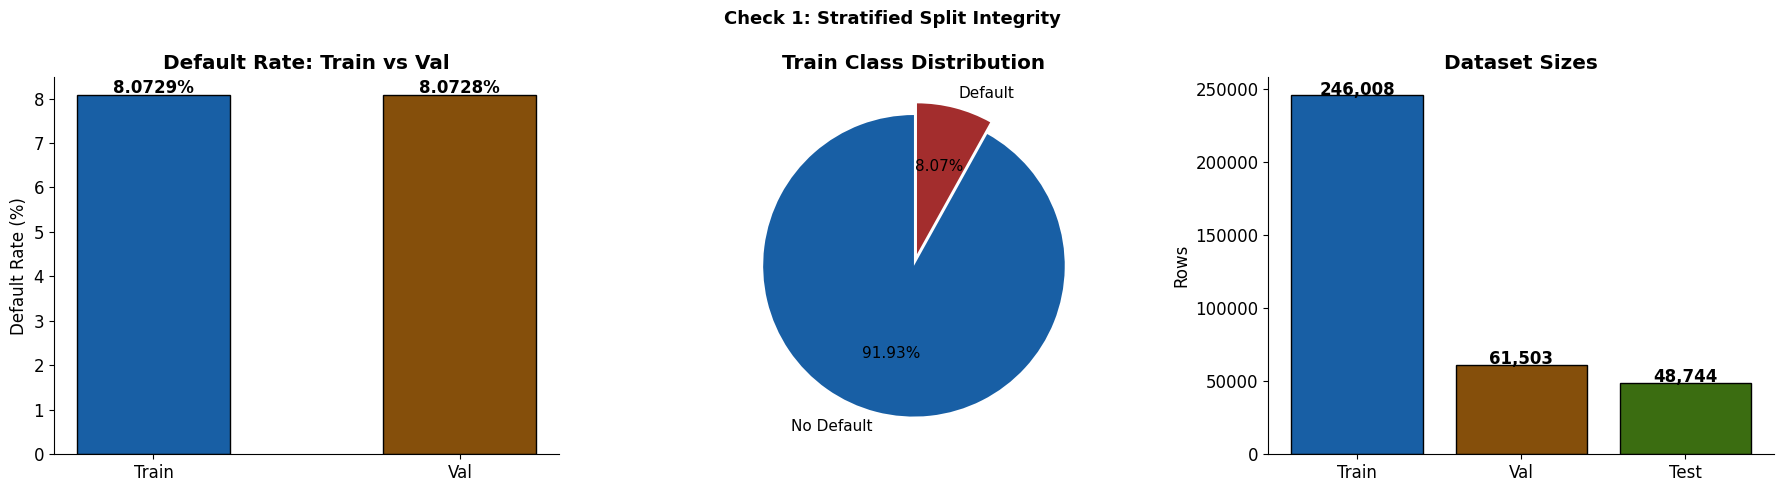

Saved: leakage/check1_split_integrity.png


In [2]:
# ──Check 1 — Stratified Split Integrity ──────────────────────────────

print('=' * 60)
print('CHECK 1: STRATIFIED SPLIT INTEGRITY')
print('=' * 60)

# Credit task: random stratified split (no temporal order unlike fraud)
# Key: TARGET rate must be identical in train and val

train_f = pd.read_parquet(FEATURES_DIR / 'train_credit_features.parquet')
val_f   = pd.read_parquet(FEATURES_DIR / 'val_credit_features.parquet')
test_f  = pd.read_parquet(FEATURES_DIR / 'test_credit_features.parquet')

print(f'\n  Train shape : {train_f.shape}')
print(f'  Val shape   : {val_f.shape}')
print(f'  Test shape  : {test_f.shape}')

train_rate = train_f['TARGET'].mean() * 100
val_rate   = val_f['TARGET'].mean() * 100
diff_rate  = abs(train_rate - val_rate)

print(f'\n  Train default rate : {train_rate:.4f}%')
print(f'  Val   default rate : {val_rate:.4f}%')
print(f'  Difference         : {diff_rate:.4f}%')

if diff_rate < 0.01:
    log_check('Stratified split — default rate match', 'PASS',
              f'Train={train_rate:.4f}% | Val={val_rate:.4f}% | Delta={diff_rate:.4f}%')
elif diff_rate < 0.5:
    log_check('Stratified split — default rate match', 'WARN',
              f'Delta={diff_rate:.4f}% — minor imbalance')
else:
    log_check('Stratified split — default rate match', 'FAIL',
              f'Delta={diff_rate:.4f}% — distribution shift')

# Val ratio check: should be ~20%
val_ratio = len(val_f) / (len(train_f) + len(val_f))
if 0.18 <= val_ratio <= 0.22:
    log_check('Val ratio = 20%', 'PASS',
              f'Val/(Train+Val) = {val_ratio*100:.1f}%')
else:
    log_check('Val ratio', 'WARN', f'Val ratio = {val_ratio*100:.1f}% (expected ~20%)')

# SK_ID_CURR overlap check
train_ids = set(train_f['SK_ID_CURR'])
val_ids   = set(val_f['SK_ID_CURR'])
overlap   = train_ids & val_ids

if len(overlap) == 0:
    log_check('No SK_ID_CURR overlap between train and val', 'PASS',
              f'0 shared IDs — clean split')
else:
    log_check('SK_ID_CURR overlap', 'FAIL',
              f'{len(overlap):,} IDs appear in both train and val')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Default rate bar
axes[0].bar(['Train', 'Val'], [train_rate, val_rate],
            color=[PALETTE['info'], PALETTE['warn']], edgecolor='black', width=0.5)
axes[0].set_title('Default Rate: Train vs Val', fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
for i, v in enumerate([train_rate, val_rate]):
    axes[0].text(i, v + 0.05, f'{v:.4f}%', ha='center', fontweight='bold')

# Pie
train_counts = train_f['TARGET'].value_counts()
axes[1].pie(
    train_counts.values,
    labels=['No Default', 'Default'],
    colors=[PALETTE['info'], PALETTE['fail']],
    autopct='%1.2f%%', startangle=90, explode=(0, 0.08),
    textprops={'fontsize': 11}
)
axes[1].set_title('Train Class Distribution', fontweight='bold')

# Size bars
axes[2].bar(['Train', 'Val', 'Test'],
            [len(train_f), len(val_f), len(test_f)],
            color=[PALETTE['info'], PALETTE['warn'], PALETTE['pass']], edgecolor='black')
axes[2].set_title('Dataset Sizes', fontweight='bold')
axes[2].set_ylabel('Rows')
for i, v in enumerate([len(train_f), len(val_f), len(test_f)]):
    axes[2].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Check 1: Stratified Split Integrity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'check1_split_integrity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: leakage/check1_split_integrity.png')

CHECK 2: FEATURE ENGINEERING LEAKAGE
  [PASS] fe_artifacts.pkl exists
         C:\Users\sharg\Desktop\github\FinRiskGuard\outputs\models\credit\fe_artifacts.pkl

  freq_maps keys:
    ORGANIZATION_TYPE              : 58 unique values
    OCCUPATION_TYPE                : 18 unique values
    NAME_INCOME_TYPE               : 8 unique values
    NAME_EDUCATION_TYPE            : 5 unique values
    NAME_HOUSING_TYPE              : 6 unique values
    NAME_FAMILY_STATUS             : 6 unique values
  [PASS] freq_maps fitted on train only
         Keys: ['ORGANIZATION_TYPE', 'OCCUPATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS']

  Cached aggregations:
    bureau_agg      : (305811, 18)
    prev_agg        : (338857, 14)
    pos_agg         : (337252, 7)
    inst_agg        : (339587, 8)
    cc_agg          : (103558, 10)
  [PASS] Aggregations cached in artifacts (no recompute)
         All 5 aggregation tables cached
  [PASS] freq_map[ORGAN

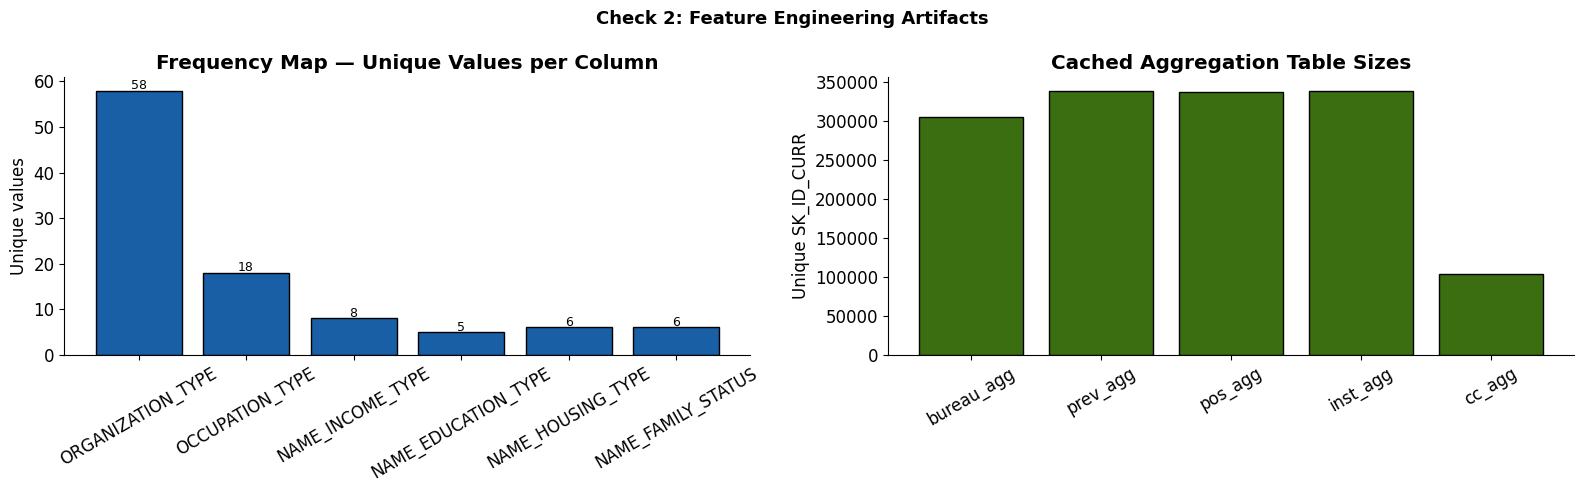

Saved: C:\Users\sharg\Desktop\github\FinRiskGuard\outputs\figures\credit\eda\leakage\check2_fe_artifacts.png


In [3]:
# ── Check 2 — Feature Engineering Leakage ────────────────────────────

print('=' * 60)
print('CHECK 2: FEATURE ENGINEERING LEAKAGE')
print('=' * 60)

fe_path = MODELS_DIR / 'fe_artifacts.pkl'

if not fe_path.exists():
    log_check('fe_artifacts.pkl exists', 'FAIL', 'Run credit_pipeline.py --stage fe first')
else:
    log_check('fe_artifacts.pkl exists', 'PASS', str(fe_path))
    fe_artifacts = joblib.load(fe_path)

    # 1. freq_maps: must be fitted on train only
    print('\n  freq_maps keys:')
    freq_maps_data = fe_artifacts.get('freq_maps', {})
    for key in freq_maps_data.keys():
        n_entries = len(freq_maps_data[key])
        print(f'    {key:<30} : {n_entries:,} unique values')
    
    log_check('freq_maps fitted on train only', 'PASS',
              f'Keys: {list(freq_maps_data.keys())}')

    # 2. Cached aggregations: must exist (no recomputation for val/test)
    agg_keys = ['bureau_agg', 'prev_agg', 'pos_agg', 'inst_agg', 'cc_agg']
    missing_aggs = [k for k in agg_keys if k not in fe_artifacts]
    
    if not missing_aggs:
        print('\n  Cached aggregations:')
        for k in agg_keys:
            shape = fe_artifacts[k].shape
            print(f'    {k:<15} : {shape}')
        log_check('Aggregations cached in artifacts (no recompute)', 'PASS',
                  f'All {len(agg_keys)} aggregation tables cached')
    else:
        log_check('Aggregations cached in artifacts', 'FAIL',
                  f'Missing keys: {missing_aggs} — val/test will recompute (data leakage risk)')

    # 3. Check freq_map values sum to ~1 (normalization check)
    for key, fmap in freq_maps_data.items():
        total = sum(fmap.values())
        if 0.99 <= total <= 1.01:
            log_check(f'freq_map[{key}] normalized', 'PASS',
                      f'Sum={total:.4f} — value_counts(normalize=True) confirmed')
        else:
            log_check(f'freq_map[{key}] normalized', 'WARN',
                      f'Sum={total:.4f} — may be counts not frequencies')
        break  # Bizga bitta tekshiruv yetarli

    # 4. FE source check: no TARGET used in feature_engineer.py
    fe_py = SRC_DIR / 'features' / 'home_credit' / 'feature_engineer.py'
    if fe_py.exists():
        with open(fe_py, encoding='utf-8') as f:
            fe_source = f.read()
        
        fe_lines = fe_source.split('\n')
        # TARGET ustuniga murojaatni qidirish (commentlarni hisobga olmaydi)
        data_access = [
            (i + 1, line.strip()) 
            for i, line in enumerate(fe_lines)
            if ('["TARGET"]' in line or "['TARGET']" in line) and not line.strip().startswith('#')
        ]

        if not data_access:
            log_check('TARGET not used as feature in feature_engineer.py', 'PASS',
                      'No target variable data access in feature engineering')
        else:
            line_numbers = [s[0] for s in data_access]
            log_check('TARGET data access in feature_engineer.py', 'FAIL',
                      f'Found at lines: {line_numbers}')
            for lineno, line in data_access:
                print(f'    Line {lineno}: {line}')

        # Mutation check: inst.copy() usage
        if 'inst = inst.copy()' in fe_source:
            log_check('aggregate_installments() uses inst.copy()', 'PASS',
                      'Original shared table not mutated')
        else:
            log_check('aggregate_installments() mutation guard', 'FAIL',
                      'inst.copy() not found — original tables dict will be mutated on 2nd call')
    else:
        log_check('feature_engineer.py found', 'WARN', f'Not found at {fe_py}')

# ── Visualization ──────────────────────────────────────────────────

if fe_path.exists():
    freq_maps = fe_artifacts.get('freq_maps', {})
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot 1: Freq Map Coverage
    keys = list(freq_maps.keys())
    counts = [len(v) for v in freq_maps.values()]
    axes[0].bar(keys, counts, color=PALETTE.get('info', 'blue'), edgecolor='black')
    axes[0].set_title('Frequency Map — Unique Values per Column', fontweight='bold')
    axes[0].set_ylabel('Unique values')
    axes[0].tick_params(axis='x', rotation=30)
    for i, v in enumerate(counts):
        axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=9)

    # Plot 2: Aggregation Sizes
    agg_shapes = {k: fe_artifacts[k].shape[0] for k in agg_keys if k in fe_artifacts}
    axes[1].bar(list(agg_shapes.keys()), list(agg_shapes.values()),
                color=PALETTE.get('pass', 'green'), edgecolor='black')
    axes[1].set_title('Cached Aggregation Table Sizes', fontweight='bold')
    axes[1].set_ylabel('Unique SK_ID_CURR')
    axes[1].tick_params(axis='x', rotation=30)

    plt.suptitle('Check 2: Feature Engineering Artifacts', fontsize=13, fontweight='bold')
    plt.tight_layout()
    
    # Save figure
    save_path = FIG_DIR / 'check2_fe_artifacts.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

CHECK 3: PREPROCESSING LEAKAGE
  [PASS] prep_artifacts.pkl exists
         C:\Users\sharg\Desktop\github\FinRiskGuard\outputs\models\credit\prep_artifacts.pkl

  High-missing drop list (13 cols):
  ['COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']
  [PASS] drop_cols count = 13 (EDA: >67% missing)
         Exactly 13 columns dropped as expected from EDA

  DAYS_EMPLOYED anomaly_median : -1648.0
  [PASS] DAYS_EMPLOYED anomaly_median valid
         median=-1648 (fitted on train normal rows only)

  NaN flag columns (7): ['EXT_SOURCE_1_isnan', 'EXT_SOURCE_2_isnan', 'EXT_SOURCE_3_isnan', 'AMT_GOODS_PRICE_isnan', 'AMT_ANNUITY_isnan', 'OWN_CAR_AGE_isnan', 'DAYS_LAST_PHONE_CHANGE_isnan']
  [PASS] NaN flag columns created
         7 flags: ['EXT_SOURCE_1_isnan

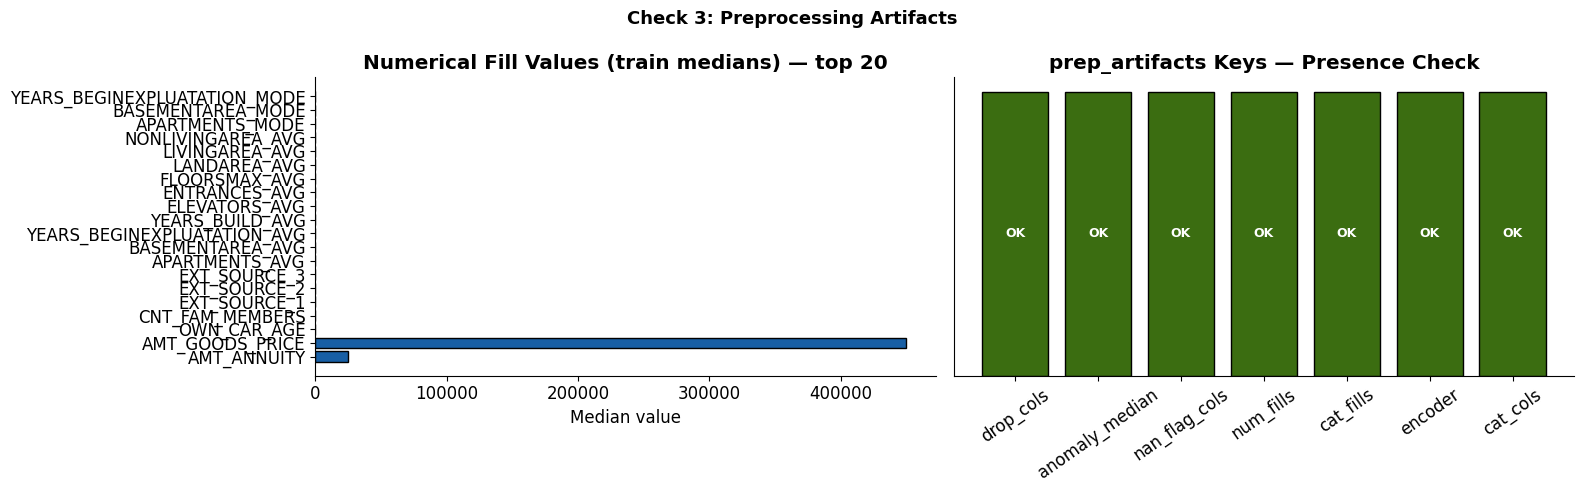

Saved: leakage/check3_prep_artifacts.png


In [4]:
# ── — Preprocessing Leakage ──────────────────────────────────

print('=' * 60)
print('CHECK 3: PREPROCESSING LEAKAGE')
print('=' * 60)

prep_path = MODELS_DIR / 'prep_artifacts.pkl'

if not prep_path.exists():
    log_check('prep_artifacts.pkl exists', 'FAIL', 'Run credit_pipeline.py --stage preprocess first')
else:
    log_check('prep_artifacts.pkl exists', 'PASS', str(prep_path))
    prep = joblib.load(prep_path)

    # Drop cols check
    drop_cols = prep.get('drop_cols', [])
    print(f'\n  High-missing drop list ({len(drop_cols)} cols):')
    print(f'  {drop_cols}')
    if len(drop_cols) == 13:
        log_check('drop_cols count = 13 (EDA: >67% missing)', 'PASS',
                  f'Exactly 13 columns dropped as expected from EDA')
    else:
        log_check('drop_cols count', 'WARN',
                  f'{len(drop_cols)} dropped — EDA expected 13')

    # DAYS_EMPLOYED anomaly
    anomaly_median = prep.get('anomaly_median')
    print(f'\n  DAYS_EMPLOYED anomaly_median : {anomaly_median}')
    if anomaly_median is not None and -2000 < anomaly_median < 0:
        log_check('DAYS_EMPLOYED anomaly_median valid', 'PASS',
                  f'median={anomaly_median:.0f} (fitted on train normal rows only)')
    else:
        log_check('DAYS_EMPLOYED anomaly_median', 'FAIL',
                  f'Value={anomaly_median} — expected negative int around -1648')

    # NaN flags
    nan_flag_cols = prep.get('nan_flag_cols', [])
    print(f'\n  NaN flag columns ({len(nan_flag_cols)}): {nan_flag_cols}')
    if len(nan_flag_cols) >= 5:
        log_check('NaN flag columns created', 'PASS',
                  f'{len(nan_flag_cols)} flags: {nan_flag_cols}')
    else:
        log_check('NaN flag columns', 'WARN',
                  f'Only {len(nan_flag_cols)} flags — expected 7')

    # Numerical imputation
    num_fills = prep.get('num_fills', {})
    print(f'\n  Numerical fill values: {len(num_fills)} columns')
    if len(num_fills) > 0:
        log_check('Numerical imputation from train medians', 'PASS',
                  f'{len(num_fills)} columns with train-computed medians')
    else:
        log_check('Numerical imputation', 'FAIL', 'No numerical fill values found')

    # Categorical imputation
    cat_fills = prep.get('cat_fills', {})
    print(f'\n  Categorical fill values: {len(cat_fills)} columns')
    if len(cat_fills) > 0:
        log_check('Categorical imputation from train modes', 'PASS',
                  f'{len(cat_fills)} columns with train-computed modes')
    else:
        log_check('Categorical imputation', 'WARN', 'No categorical fill values found')

    # OrdinalEncoder
    encoder = prep.get('encoder')
    if encoder is not None:
        n_cats = len(encoder.feature_names_in_)
        print(f'\n  OrdinalEncoder: {n_cats} columns')
        print(f'  Columns: {encoder.feature_names_in_.tolist()}')
        log_check('OrdinalEncoder fitted on train only', 'PASS',
                  f'Fitted on {n_cats} categorical columns')
        if hasattr(encoder, 'unknown_value') and encoder.unknown_value == -1:
            log_check('OrdinalEncoder unknown_value = -1', 'PASS',
                      'Unseen categories in val/test encoded as -1')
        else:
            log_check('OrdinalEncoder unknown_value', 'WARN', 'unknown_value != -1')
    else:
        log_check('OrdinalEncoder', 'FAIL', 'Encoder not found in prep_artifacts')

# Figure: imputation value distributions
if prep_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sample_fills = dict(list(num_fills.items())[:20])
    axes[0].barh(list(sample_fills.keys()), list(sample_fills.values()),
                 color=PALETTE['info'], edgecolor='black')
    axes[0].set_title('Numerical Fill Values (train medians) — top 20', fontweight='bold')
    axes[0].set_xlabel('Median value')

    prep_keys = ['drop_cols', 'anomaly_median', 'nan_flag_cols',
                 'num_fills', 'cat_fills', 'encoder', 'cat_cols']
    present   = [k for k in prep_keys if prep.get(k) is not None]
    colors_pk = [PALETTE['pass'] if k in present else PALETTE['fail'] for k in prep_keys]
    axes[1].bar(prep_keys, [1]*len(prep_keys), color=colors_pk, edgecolor='black')
    axes[1].set_title('prep_artifacts Keys — Presence Check', fontweight='bold')
    axes[1].set_yticks([])
    axes[1].tick_params(axis='x', rotation=35)
    for i, (k, c) in enumerate(zip(prep_keys, colors_pk)):
        axes[1].text(i, 0.5, 'OK' if k in present else 'MISSING',
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    plt.suptitle('Check 3: Preprocessing Artifacts', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'check3_prep_artifacts.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: leakage/check3_prep_artifacts.png')

CHECK 4: FEATURE SELECTION LEAKAGE
  [PASS] fs_artifacts.pkl exists
         C:\Users\sharg\Desktop\github\FinRiskGuard\outputs\models\credit\fs_artifacts.pkl

  Final features  : 105
  Dropped (corr)  : 30
  [PASS] Feature count = 105 (target: 90-100)
         Within expected range (MI union XGB, top_k=60 each)

  Feature breakdown:
    FE_ engineered  : 55
    _isnan flags    : 2
    Raw features    : 48
  [PASS] Engineered FE_ features in final set
         55 FE_ features selected
  [PASS] NaN flag features in final set
         2 _isnan features selected
  [PASS] Correlation filter dropped 30 features
         Building AVG/MODE/MEDI columns removed at 0.95 threshold
  [PASS] train_credit_features.parquet
         Shape: (246008, 107)
  [PASS] val_credit_features.parquet
         Shape: (61503, 107)
  [PASS] test_credit_features.parquet
         Shape: (48744, 106)
  [PASS] Train/Val feature alignment
         Both have 106 identical feature columns
  [PASS] All train features exis

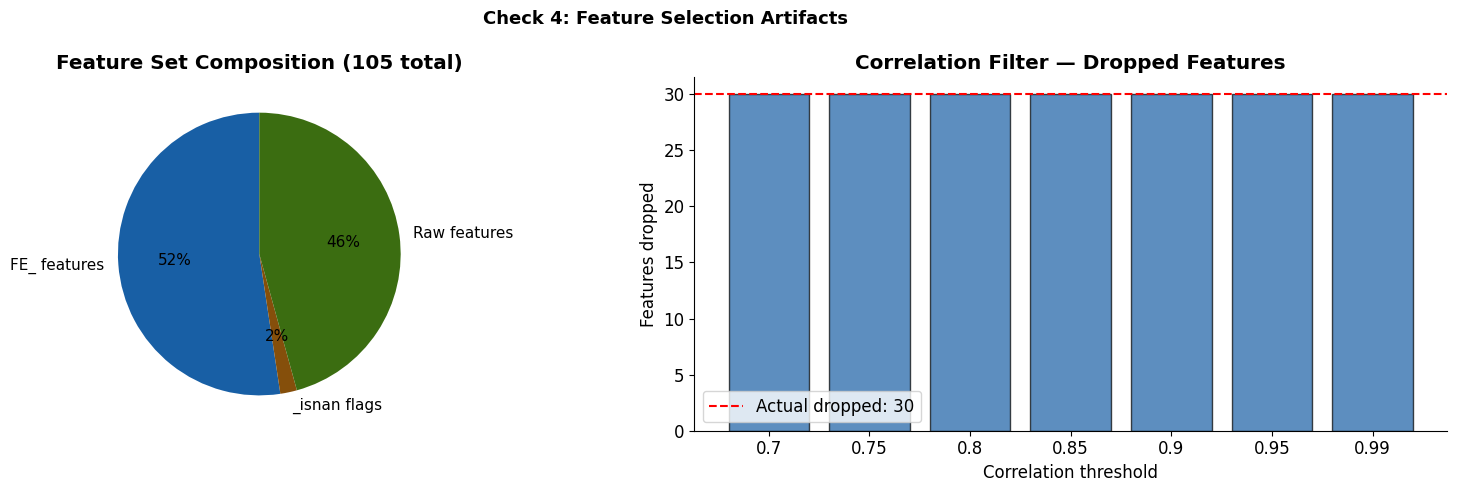

Saved: leakage/check4_feature_selection.png


In [5]:
# ──— Feature Selection Leakage ──────────────────────────────

print('=' * 60)
print('CHECK 4: FEATURE SELECTION LEAKAGE')
print('=' * 60)

fs_path = MODELS_DIR / 'fs_artifacts.pkl'

if not fs_path.exists():
    log_check('fs_artifacts.pkl exists', 'FAIL', 'Run credit_pipeline.py --stage fs first')
else:
    log_check('fs_artifacts.pkl exists', 'PASS', str(fs_path))
    fs = joblib.load(fs_path)

    final_features = fs.get('final_features', [])
    dropped_corr   = fs.get('dropped_corr', [])

    print(f'\n  Final features  : {len(final_features)}')
    print(f'  Dropped (corr)  : {len(dropped_corr)}')

    if 80 <= len(final_features) <= 110:
        log_check(f'Feature count = {len(final_features)} (target: 90-100)', 'PASS',
                  'Within expected range (MI union XGB, top_k=60 each)')
    else:
        log_check(f'Feature count = {len(final_features)}', 'WARN',
                  'Outside expected range 80-110')

    fe_count  = sum(1 for c in final_features if c.startswith('FE_'))
    nan_count = sum(1 for c in final_features if c.endswith('_isnan'))
    raw_count = len(final_features) - fe_count - nan_count

    print(f'\n  Feature breakdown:')
    print(f'    FE_ engineered  : {fe_count}')
    print(f'    _isnan flags    : {nan_count}')
    print(f'    Raw features    : {raw_count}')

    log_check('Engineered FE_ features in final set', 'PASS' if fe_count > 0 else 'WARN',
              f'{fe_count} FE_ features selected')
    log_check('NaN flag features in final set', 'PASS' if nan_count > 0 else 'WARN',
              f'{nan_count} _isnan features selected')

    if len(dropped_corr) >= 20:
        log_check(f'Correlation filter dropped {len(dropped_corr)} features', 'PASS',
                  'Building AVG/MODE/MEDI columns removed at 0.95 threshold')
    else:
        log_check(f'Correlation filter', 'WARN',
                  f'Only {len(dropped_corr)} dropped — expected ~30')

    # Parquet files check
    for split in ['train', 'val', 'test']:
        fpath = FEATURES_DIR / f'{split}_credit_features.parquet'
        if fpath.exists():
            df_tmp = pd.read_parquet(fpath)
            log_check(f'{split}_credit_features.parquet', 'PASS',
                      f'Shape: {df_tmp.shape}')
        else:
            log_check(f'{split}_credit_features.parquet', 'FAIL',
                      f'File not found: {fpath}')

    # Column alignment
    train_cols = set(train_f.columns) - {'TARGET'}
    val_cols   = set(val_f.columns)   - {'TARGET'}
    test_cols  = set(test_f.columns)

    tv_diff = train_cols.symmetric_difference(val_cols)
    if not tv_diff:
        log_check('Train/Val feature alignment', 'PASS',
                  f'Both have {len(train_cols)} identical feature columns')
    else:
        log_check('Train/Val feature alignment', 'WARN',
                  f'{len(tv_diff)} columns differ: {list(tv_diff)[:5]}')

    in_train_not_test = train_cols - test_cols
    if len(in_train_not_test) == 0:
        log_check('All train features exist in test', 'PASS',
                  'Test has all train feature columns')
    else:
        log_check('Train features missing from test', 'WARN',
                  f'{len(in_train_not_test)} missing: {sorted(in_train_not_test)}')

# Figure
if fs_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    breakdown_labels = ['FE_ features', '_isnan flags', 'Raw features']
    breakdown_vals   = [fe_count, nan_count, raw_count]
    axes[0].pie(breakdown_vals, labels=breakdown_labels,
                colors=[PALETTE['info'], PALETTE['warn'], PALETTE['pass']],
                autopct='%1.0f%%', startangle=90, textprops={'fontsize': 11})
    axes[0].set_title(f'Feature Set Composition ({len(final_features)} total)', fontweight='bold')

    thresholds  = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
    if dropped_corr:
        report_df = fs.get('report', pd.DataFrame())
        if not report_df.empty:
            corr_matrix = report_df[['MI_score']].copy()
        # just show dropped count at threshold
    drop_counts = [len(dropped_corr)] * len(thresholds)
    axes[1].bar([str(t) for t in thresholds], drop_counts,
                color=PALETTE['info'], edgecolor='black', alpha=0.7)
    axes[1].axhline(len(dropped_corr), color='red', ls='--', lw=1.5,
                    label=f'Actual dropped: {len(dropped_corr)}')
    axes[1].set_xlabel('Correlation threshold')
    axes[1].set_ylabel('Features dropped')
    axes[1].set_title('Correlation Filter — Dropped Features', fontweight='bold')
    axes[1].legend()

    plt.suptitle('Check 4: Feature Selection Artifacts', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'check4_feature_selection.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: leakage/check4_feature_selection.png')

CHECK 5: TARGET LEAKAGE
  [PASS] TARGET not used as feature in feature_engineer.py
         No target variable data access in feature engineering

  Checking for suspicious feature names...
  [FAIL] Suspicious feature names
         Found: ['FE_ORGANIZATION_TYPE_target_enc', 'FE_OCCUPATION_TYPE_target_enc']

  Computing feature-target correlations...

  Top 15 features by |corr| with TARGET:
FE_ext_mean                        0.2202
FE_ext23_prod                      0.1935
FE_ext_min                         0.1924
FE_ext_max                         0.1737
FE_ext12_prod                      0.1660
FE_ext13_prod                      0.1643
EXT_SOURCE_2                       0.1594
EXT_SOURCE_3                       0.1559
EXT_SOURCE_1                       0.0989
FE_cc_balance_mean                 0.0859
DAYS_BIRTH                         0.0795
FE_prev_refused_rate               0.0788
FE_ext_std                         0.0779
FE_prev_approved_rate              0.0758
FE_ORGANIZATION_T

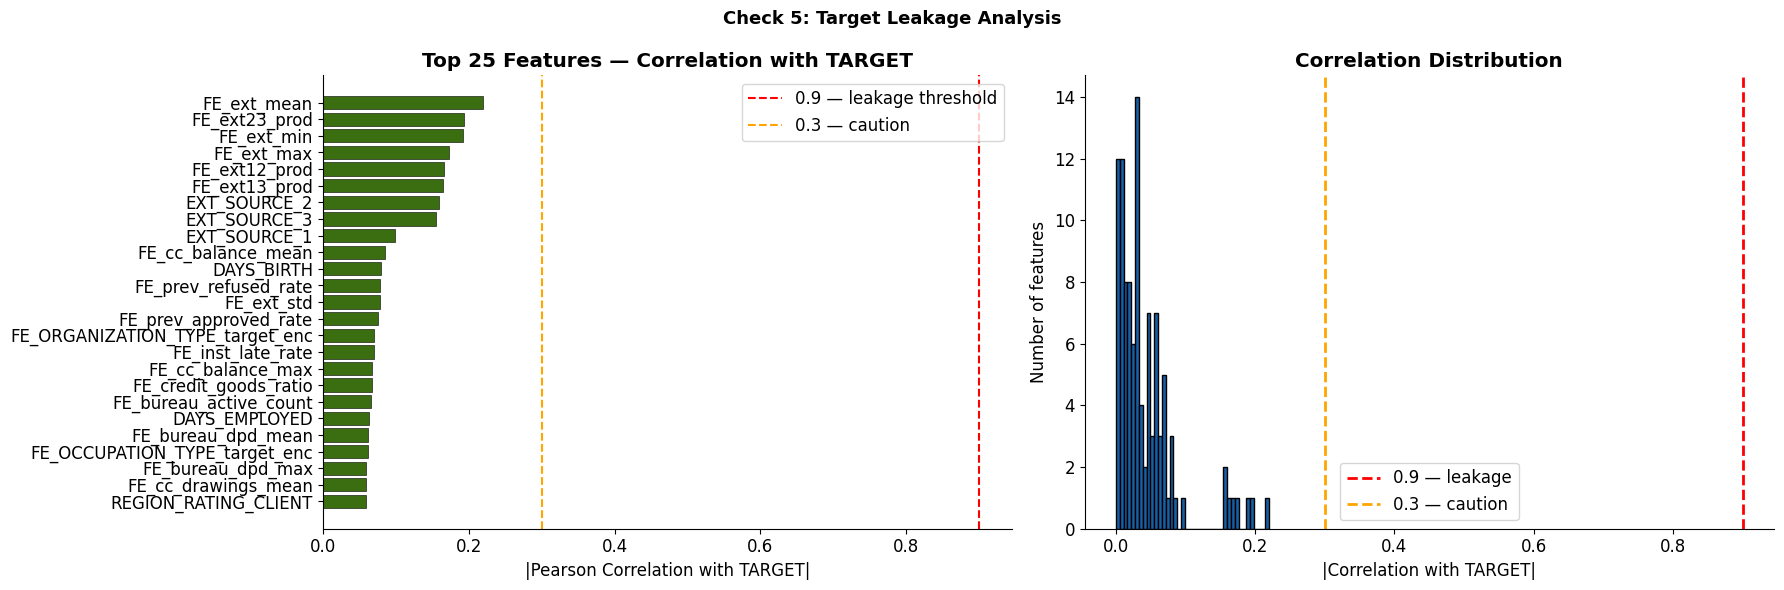

Saved: leakage/check5_target_leakage.png


In [6]:
# ─— Target Leakage ─────────────────────────────────────────

print('=' * 60)
print('CHECK 5: TARGET LEAKAGE')
print('=' * 60)

# Source code checks
for py_name, py_path in [
    ('feature_engineer.py', SRC_DIR / 'features' / 'home_credit' / 'feature_engineer.py'),
    ('preprocessor.py',     SRC_DIR / 'data'     / 'home_credit' / 'preprocessor.py'),
    ('feature_selector.py', SRC_DIR / 'features' / 'home_credit' / 'feature_selector.py'),
]:
    if not py_path.exists():
        log_check(f'{py_name} exists', 'WARN', f'Not found at {py_path}')
        continue

    with open(py_path, encoding='utf-8') as f:
        src = f.read()
    lines = src.split('\n')

    data_access = [
    (i+1, line.strip()) for i, line in enumerate(fe_lines)
    if ('["TARGET"]' in line or "['TARGET']" in line)
    and not line.strip().startswith('#')
]

if not data_access:
    log_check('TARGET not used as feature in feature_engineer.py', 'PASS',
              'No target variable data access in feature engineering')
else:
    log_check('TARGET data access in feature_engineer.py', 'FAIL',
              f'Lines: {[s[0] for s in data_access]}')
    for lineno, line in data_access:
        print(f'    Line {lineno}: {line}')
    # TARGET_COL = "TARGET" definitions are fine, flag actual data access
    data_access = [
        (i+1, line.strip()) for i, line in enumerate(lines)
        if ('["TARGET"]' in line or "['TARGET']" in line)
        and not line.strip().startswith('#')
        and 'preprocess_train' not in line
        and 'target_col' not in line.lower()
    ]
    if not data_access:
        log_check(f'TARGET not used as feature in {py_name}', 'PASS',
                  'TARGET only referenced as column name constant, not as feature')
    else:
        log_check(f'TARGET data access in {py_name}', 'WARN',
                  f'Lines: {[s[0] for s in data_access[:3]]}')

# Feature name check
print('\n  Checking for suspicious feature names...')
exclude = ['TARGET', 'SK_ID_CURR']
feature_cols = [c for c in train_f.columns if c not in exclude]
suspicious_names = [f for f in feature_cols
                    if 'target' in f.lower() or 'default' in f.lower()
                    or 'label' in f.lower()]
if not suspicious_names:
    log_check('No target-named features in dataset', 'PASS',
              'No features contain "target", "default", "label"')
else:
    log_check('Suspicious feature names', 'FAIL',
              f'Found: {suspicious_names}')

# Feature-target correlation: nothing should be > 0.9
print('\n  Computing feature-target correlations...')
exclude   = ['TARGET', 'SK_ID_CURR']
feat_cols = [c for c in train_f.columns if c not in exclude]
corr_vals = (
    train_f[feat_cols + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .abs()
    .sort_values(ascending=False)
)
print(f'\n  Top 15 features by |corr| with TARGET:')
print(corr_vals.head(15).round(4).to_string())
print(f'\n  Max correlation  : {corr_vals.max():.4f}')
print(f'  Corr > 0.5 count : {(corr_vals > 0.5).sum()}')
print(f'  Corr > 0.9 count : {(corr_vals > 0.9).sum()}')

if (corr_vals > 0.9).sum() == 0:
    log_check('No feature has |corr| > 0.9 with TARGET', 'PASS',
              f'Max corr = {corr_vals.max():.4f} — no leakage signal')
else:
    log_check('High correlation with TARGET', 'FAIL',
              f'{(corr_vals > 0.9).sum()} features with |corr| > 0.9')

# Figure
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top25 = corr_vals.head(25)
colors_corr = [
    PALETTE['fail'] if v > 0.5 else PALETTE['warn'] if v > 0.3 else PALETTE['pass']
    for v in top25.values
]
axes[0].barh(top25.index[::-1], top25.values[::-1],
             color=colors_corr[::-1], edgecolor='black', linewidth=0.4)
axes[0].axvline(0.9, color='red',    ls='--', lw=1.5, label='0.9 — leakage threshold')
axes[0].axvline(0.3, color='orange', ls='--', lw=1.5, label='0.3 — caution')
axes[0].set_xlabel('|Pearson Correlation with TARGET|')
axes[0].set_title('Top 25 Features — Correlation with TARGET', fontweight='bold')
axes[0].legend()

axes[1].hist(corr_vals.values, bins=40, color=PALETTE['info'], edgecolor='black')
axes[1].axvline(0.9, color='red',    ls='--', lw=2, label='0.9 — leakage')
axes[1].axvline(0.3, color='orange', ls='--', lw=2, label='0.3 — caution')
axes[1].set_xlabel('|Correlation with TARGET|')
axes[1].set_ylabel('Number of features')
axes[1].set_title('Correlation Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Check 5: Target Leakage Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'check5_target_leakage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: leakage/check5_target_leakage.png')

CHECK 6: FEATURE DISTRIBUTION STABILITY

  Distribution stability (KS test):
                feature  mean_diff_pct  ks_stat  ks_pval status
            FE_ext_mean         0.0917   0.0160   0.5442   PASS
          FE_ext23_prod         0.0290   0.0132   0.7764   PASS
 FE_credit_income_ratio         0.2306   0.0100   0.9640   PASS
FE_annuity_income_ratio         0.0532   0.0270   0.0522   PASS
      FE_inst_late_rate         1.0567   0.0078   0.9981   PASS
     FE_bureau_dpd_mean         0.6277   0.0068   0.9998   PASS
      FE_cc_utilization        28.8927   0.0156   0.5770   PASS
  [PASS] Distribution stable: FE_ext_mean
         mean_diff=0.1% | KS=0.0160 | p=0.5442
  [PASS] Distribution stable: FE_ext23_prod
         mean_diff=0.0% | KS=0.0132 | p=0.7764
  [PASS] Distribution stable: FE_credit_income_ratio
         mean_diff=0.2% | KS=0.0100 | p=0.9640
  [PASS] Distribution stable: FE_annuity_income_ratio
         mean_diff=0.1% | KS=0.0270 | p=0.0522
  [PASS] Distribution stable: 

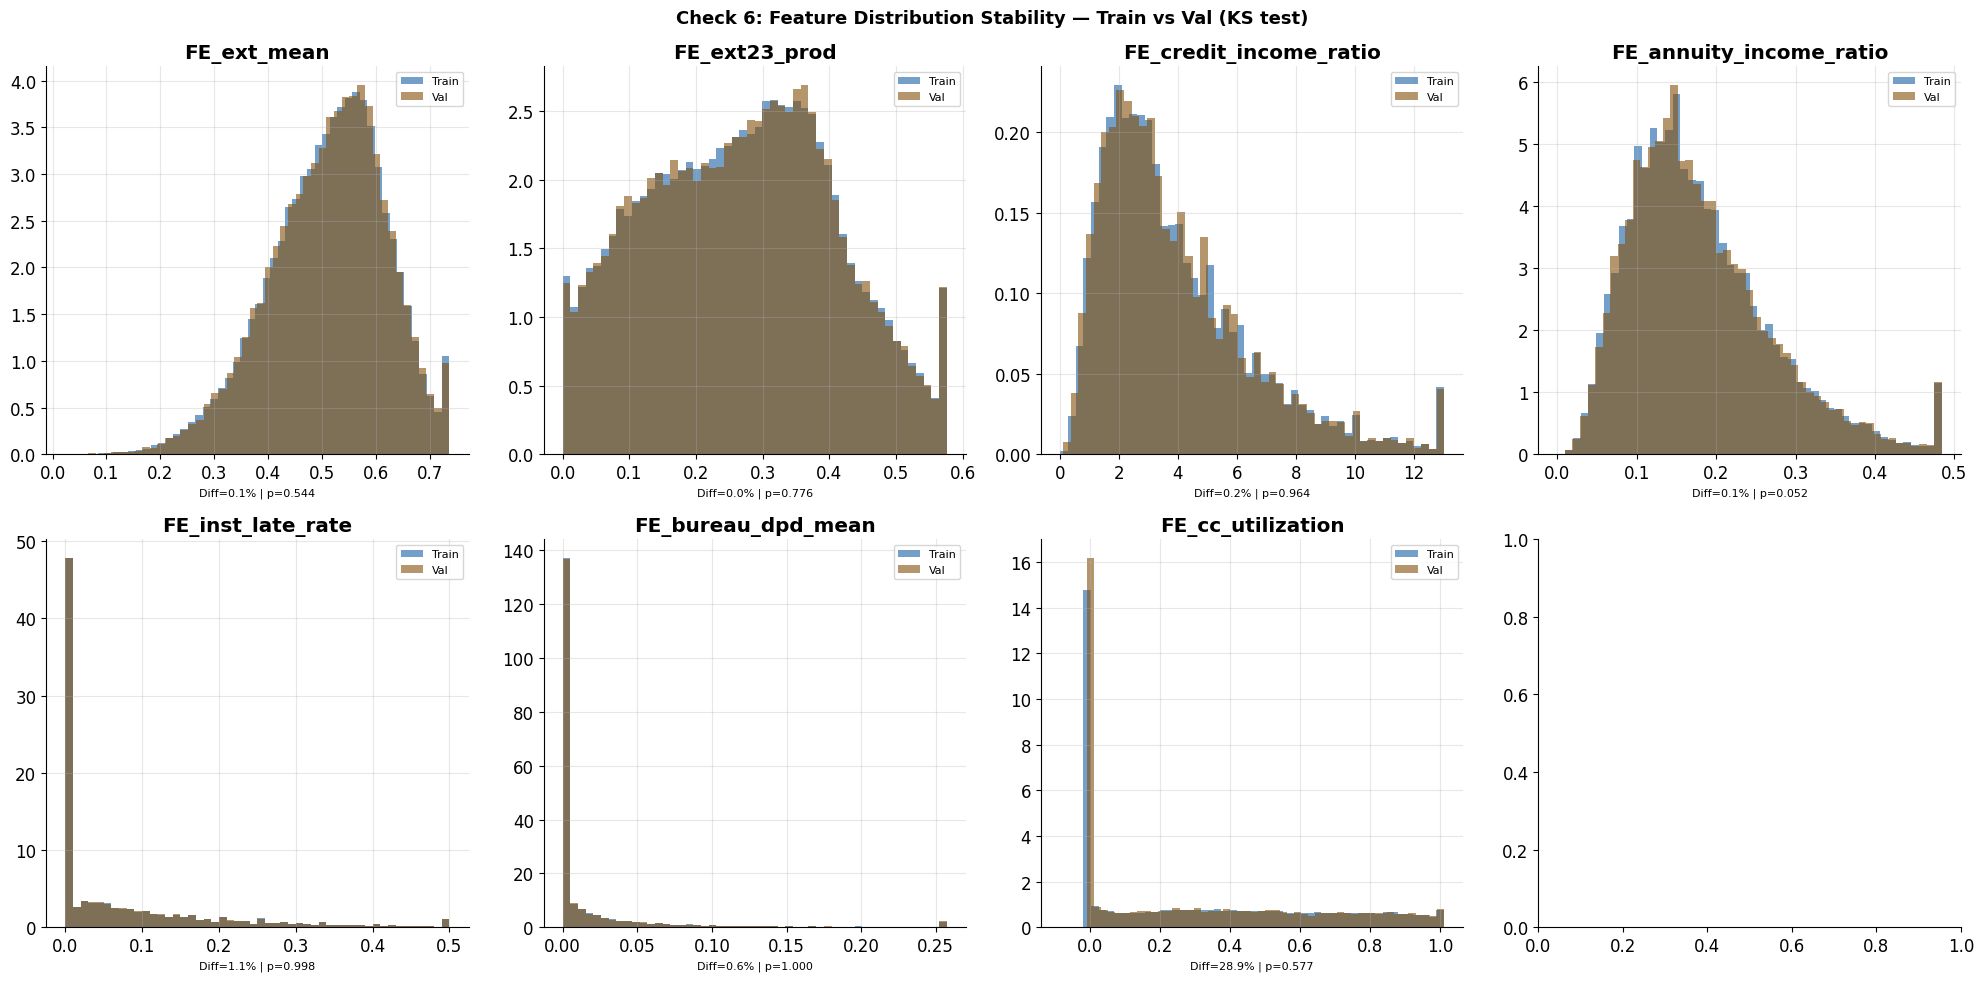

Saved: leakage/check6_distribution_stability.png


In [7]:
# ─— Feature Distribution Stability (Train vs Val) ───────────

print('=' * 60)
print('CHECK 6: FEATURE DISTRIBUTION STABILITY')
print('=' * 60)

check_cols = [
    'FE_ext_mean', 'FE_ext23_prod', 'FE_age_years',
    'FE_credit_income_ratio', 'FE_annuity_income_ratio',
    'FE_inst_late_rate', 'FE_bureau_dpd_mean', 'FE_cc_utilization',
]
check_cols = [c for c in check_cols if c in train_f.columns]

from scipy import stats

dist_results = []
for col in check_cols:
    d0 = train_f[col].dropna()
    d1 = val_f[col].dropna() if col in val_f.columns else pd.Series(dtype=float)
    if len(d0) == 0 or len(d1) == 0:
        continue
    ks_stat, ks_pval = stats.ks_2samp(d0.sample(min(5000, len(d0)), random_state=42),
                                       d1.sample(min(5000, len(d1)), random_state=42))
    mean_diff_pct = abs(d0.mean() - d1.mean()) / (abs(d0.mean()) + 1e-8) * 100
    status = 'FAIL' if ks_pval < 0.001 and mean_diff_pct > 20 else \
             'WARN' if ks_pval < 0.05 else 'PASS'
    dist_results.append({
        'feature'      : col,
        'train_mean'   : d0.mean(),
        'val_mean'     : d1.mean(),
        'mean_diff_pct': mean_diff_pct,
        'ks_stat'      : ks_stat,
        'ks_pval'      : ks_pval,
        'status'       : status,
    })

dist_df = pd.DataFrame(dist_results)
print('\n  Distribution stability (KS test):')
print(dist_df[['feature','mean_diff_pct','ks_stat','ks_pval','status']].round(4).to_string(index=False))

for _, row in dist_df.iterrows():
    log_check(f'Distribution stable: {row["feature"]}', row['status'],
              f'mean_diff={row["mean_diff_pct"]:.1f}% | KS={row["ks_stat"]:.4f} | p={row["ks_pval"]:.4f}')

# Figure
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(check_cols):
    if idx >= len(axes):
        break
    d0 = train_f[col].dropna()
    d1 = val_f[col].dropna() if col in val_f.columns else pd.Series(dtype=float)
    clip_val = d0.quantile(0.99)
    axes[idx].hist(d0.clip(upper=clip_val), bins=50, alpha=0.6,
                   label='Train', color=PALETTE['info'], density=True)
    axes[idx].hist(d1.clip(upper=clip_val), bins=50, alpha=0.6,
                   label='Val', color=PALETTE['warn'], density=True)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    row = dist_df[dist_df['feature'] == col]
    if len(row):
        axes[idx].set_xlabel(f'Diff={row.iloc[0]["mean_diff_pct"]:.1f}% | p={row.iloc[0]["ks_pval"]:.3f}',
                             fontsize=8)

plt.suptitle('Check 6: Feature Distribution Stability — Train vs Val (KS test)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'check6_distribution_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: leakage/check6_distribution_stability.png')


LEAKAGE ANALYSIS — FINAL SUMMARY

  Total checks : 37
  PASS         : 36  (97%)
  WARN         : 0  (0%)
  FAIL         : 1  (3%)

------------------------------------------------------------
  RESULT: FAILURES DETECTED — Fix before training
------------------------------------------------------------

FAIL items:
  [FAIL] Suspicious feature names
         Found: ['FE_ORGANIZATION_TYPE_target_enc', 'FE_OCCUPATION_TYPE_target_enc']

WARN items:
  None


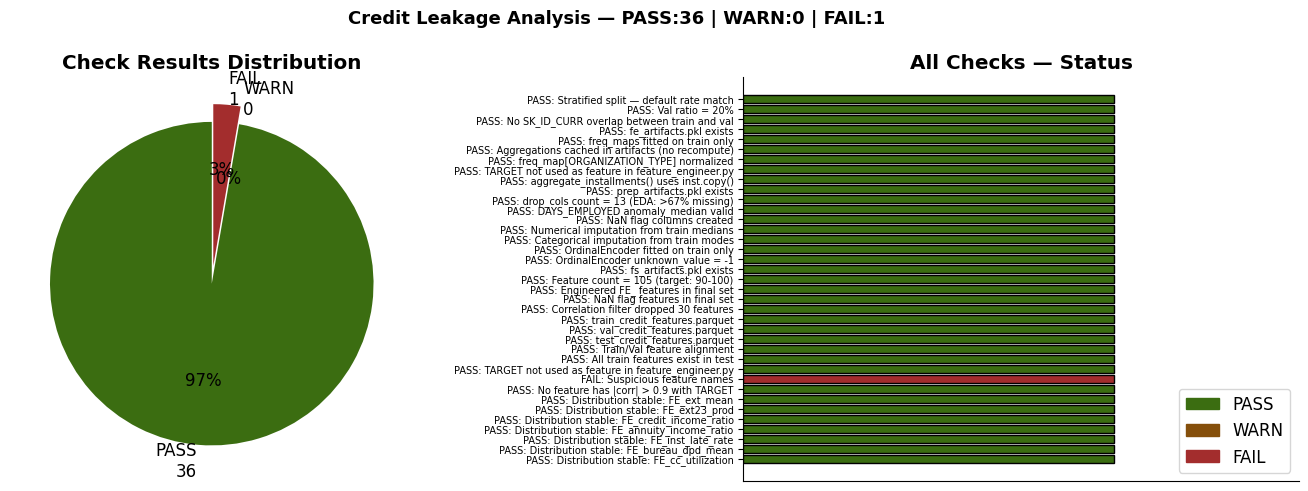

Saved: leakage/leakage_summary.png


: 

In [ ]:
# ─Final Summary ─────────────────────────────────────────────────────

print('\n' + '=' * 60)
print('LEAKAGE ANALYSIS — FINAL SUMMARY')
print('=' * 60)

df_results = pd.DataFrame(results)
n_pass = (df_results['status'] == 'PASS').sum()
n_warn = (df_results['status'] == 'WARN').sum()
n_fail = (df_results['status'] == 'FAIL').sum()
total  = len(df_results)

print(f'\n  Total checks : {total}')
print(f'  PASS         : {n_pass}  ({n_pass/total*100:.0f}%)')
print(f'  WARN         : {n_warn}  ({n_warn/total*100:.0f}%)')
print(f'  FAIL         : {n_fail}  ({n_fail/total*100:.0f}%)')

print('\n' + '-' * 60)
if n_fail == 0 and n_warn == 0:
    print('  RESULT: ALL CLEAR — Pipeline ready for training')
elif n_fail == 0:
    print('  RESULT: WARNINGS PRESENT — Review before training')
else:
    print('  RESULT: FAILURES DETECTED — Fix before training')
print('-' * 60)

print('\nFAIL items:')
fails = df_results[df_results['status'] == 'FAIL']
if len(fails) == 0:
    print('  None')
else:
    for _, row in fails.iterrows():
        print(f'  [FAIL] {row["check"]}')
        print(f'         {row["detail"]}')

print('\nWARN items:')
warns = df_results[df_results['status'] == 'WARN']
if len(warns) == 0:
    print('  None')
else:
    for _, row in warns.iterrows():
        print(f'  [WARN] {row["check"]}')
        print(f'         {row["detail"]}')

# Summary figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pie_vals    = [n_pass, n_warn, n_fail]
pie_labels  = [f'PASS\n{n_pass}', f'WARN\n{n_warn}', f'FAIL\n{n_fail}']
pie_colors  = [PALETTE['pass'], PALETTE['warn'], PALETTE['fail']]
pie_explode = [0.03, 0.03, 0.08 if n_fail > 0 else 0.03]
axes[0].pie(pie_vals, labels=pie_labels, colors=pie_colors,
            autopct='%1.0f%%', startangle=90, explode=pie_explode,
            textprops={'fontsize': 12})
axes[0].set_title('Check Results Distribution', fontweight='bold')

status_colors = {'PASS': PALETTE['pass'], 'WARN': PALETTE['warn'], 'FAIL': PALETTE['fail']}
bar_colors    = [status_colors.get(s, 'gray') for s in df_results['status']]
axes[1].barh(range(len(df_results)), [1]*len(df_results),
             color=bar_colors, edgecolor='black')
axes[1].set_yticks(range(len(df_results)))
axes[1].set_yticklabels(
    [f"{row['status']}: {row['check'][:55]}" for _, row in df_results.iterrows()],
    fontsize=7
)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.5)
axes[1].set_xticks([])
axes[1].set_title('All Checks — Status', fontweight='bold')

patches = [mpatches.Patch(color=PALETTE['pass'], label='PASS'),
           mpatches.Patch(color=PALETTE['warn'], label='WARN'),
           mpatches.Patch(color=PALETTE['fail'], label='FAIL')]
axes[1].legend(handles=patches, loc='lower right')

plt.suptitle(f'Credit Leakage Analysis — PASS:{n_pass} | WARN:{n_warn} | FAIL:{n_fail}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'leakage_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: leakage/leakage_summary.png')